# 03 — H3 security / material audit (human review)

Functional classification: emotional security vs material/economic security vs status
display. Classify interaction **function**, not the object mentioned (a gown can be
status display, gift-as-care, or neither).

Saved Pass A/B/C + evidence packets only; rating cells stay blinded.
Special focus: leaf `1.6` (appearance) — Stage 10 found it on-label but the H3 question
is whether appearance content is doing *security* work.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import review_display as rd
from src.stage11_refined_construct_analysis.analysis.constructs import normalize_code

ctx = nh.setup("03_h3_security_material_audit")
cfg = ctx.cfg
HYP = "H3"
CODE_COL = "security_code"

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit


## 1. Overview — every H3 topic with labels

In [2]:
master = nh.load_master(cfg)
h3 = master[master[CODE_COL].notna()].copy()
h3["code_norm"] = h3[CODE_COL].map(normalize_code)
print(f"H3-coded topics: {len(h3)}")

overview = rd.annotation_overview(h3, CODE_COL, extra_cols=["secondary_id"])
display(overview[["topic", "taxonomy", "code", "code_norm", "mixed", "agree"]].head(60))
ctx.save_table(overview, "h3_topic_overview_labeled")
display(h3[CODE_COL].value_counts().head(20).to_frame("n"))
display(h3["code_norm"].value_counts(dropna=False).to_frame("n_norm"))

H3-coded topics: 82


,topic,taxonomy,code,code_norm,mixed,agree
0,18 — Ordering A Gown For Her,1.6 — Character Appearance & Self-Presentation,S13,S13,False,H3
1,77 — Haircut and Grooming Offered,1.6 — Character Appearance & Self-Presentation,S13,S13,False,H3
2,127 — Photographer Reviewing Pictures,1.6 — Character Appearance & Self-Presentation,S0,S0,False,H3
3,170 — Staying Close Despite Long Separation,1.6 — Character Appearance & Self-Presentation,S13,S13,False,H3
4,171 — Staring at Her Own Reflection,1.6 — Character Appearance & Self-Presentation,S13,S13,False,H3
5,192 — Peeking Through The Window,1.6 — Character Appearance & Self-Presentation,S0,S0,False,H3
6,209 — Flowers Held With Guilty Glance,1.6 — Character Appearance & Self-Presentation,S0,S0,False,
7,218 — Resenting Someone More Attractive,1.6 — Character Appearance & Self-Presentation,S13,S13,False,H3
8,241 — Calling Someone A Stubborn Idiot,1.6 — Character Appearance & Self-Presentation,S0,S0,False,
9,253 — Hair Pinned Up in Style,1.6 — Character Appearance & Self-Presentation,S13,S13,False,H3


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_topic_overview_labeled.csv  (82 rows)


,n
security_code,
S0,42
S1,17
S13,7
S4,4
S5,3
S9,2
S2,2
S11,1
S3,1


,n_norm
code_norm,
S0,42
S1,17
S13,7
S4,4
S5,3
S9,2
S2,2
S11,1
S3,1


## 2. Lexical vs contextual agreement

In [3]:
lex = nh.load_audit_jsonl(cfg, HYP, "A")
ctxu = nh.load_audit_jsonl(cfg, HYP, "B")
adj = nh.load_audit_jsonl(cfg, HYP, "C")
lex_idx = rd.audit_index(lex)
ctx_idx = rd.audit_index(ctxu)
adj_idx = rd.audit_index(adj)

agree = rd.agreement_table(h3, lex_idx, ctx_idx, adj_idx, hyp=HYP)
if not agree.empty:
    print(
        f"Lexical–contextual agreement: {agree['agree'].mean():.1%} "
        f"({int(agree['agree'].sum())}/{len(agree)})"
    )
    ctx.save_table(agree, "h3_lexical_contextual_agreement")
    disagree = agree[~agree["agree"]]
    print(f"Disagreements: {len(disagree)}")
    display(
        disagree[
            ["topic", "taxonomy", "code_a", "code_b", "code_c", "rationale_a", "rationale_b"]
        ].head(30)
    )

Lexical–contextual agreement: 59.8% (49/82)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_lexical_contextual_agreement.csv  (82 rows)
Disagreements: 33


,topic,taxonomy,code_a,code_b,code_c,rationale_a,rationale_b
11,52 — Talking About Dogs and Animals,4.2 — Ongoing Courtship & Everyday Relational ...,S6,S0,S0,"Main keywords (dog, pet, puppy, bear, lion) ar...",The overwhelming majority of sentences in this...
14,59 — Mother's Disapproval Looms,"5.1 — Family, Kinship & Parenthood",S1,S0,S0,The keyword cluster centres on mother-child re...,The overwhelming majority of sentences in this...
15,61 — Planning to Exchange Rings,8.3a — Commitment Symbols & Love Tokens,S14,MIXED,S4,"All four keyword lists centre on rings, neckla...",Topic 61 centres on jewellery and body adornme...
17,65 — Declaring A True Partnership,"4.5 — Reconciliation, Commitments & HEA",S4,S2,S4,"Main keywords (date, dating, together, dated, ...",The topic centers on romantic pairing and shar...
19,75 — Talking About Being A Father,"5.1 — Family, Kinship & Parenthood",S1,S0,S0,All four keyword lists converge on father-chil...,All sentences in this topic reference father/d...
21,81 — Mentioning A Brother,"5.1 — Family, Kinship & Parenthood",S2,S0,S0,"Main keywords (brother, brothers, siblings, si...",The overwhelming majority of sentences in this...
22,83 — Reassured About Eating Regularly,"4.6 — Emotional Safety, Reassurance & Caretaking",S5,S0,S5,"All four keyword lists centre on eating, hunge...",The overwhelming majority of sentences are sim...
23,86 — First Name Used at Last,4.2 — Ongoing Courtship & Everyday Relational ...,S1,S0,S0,"Main keywords (name, nickname, real, knew) poi...",The overwhelming majority of sentences are sim...
25,93 — Meal Plans Casually Arranged,4.2 — Ongoing Courtship & Everyday Relational ...,S5,S2,S2,All four keyword lists converge on shared meal...,The topic centres on shared meals — invitation...
29,116 — Sharing A Meal Together,4.2 — Ongoing Courtship & Everyday Relational ...,S5,S0,S0,"Main keywords (plate, fork, sandwich, bowl, br...","The topic clusters around eating utensils, pla..."


## 3. Appearance leaf (`1.6`) functional decomposition

What to check in the cards: is the prose describing bodies/clothes as craft ornament,
as wealth/status signalling, or as care/security? The object in the sentence is not the
construct.

In [4]:
app = h3[h3["current_taxonomy_id"] == "1.6"].copy()
print(f"Appearance topics in H3 audit: {len(app)}")
app_overview = rd.annotation_overview(app, CODE_COL, extra_cols=["secondary_id"])
display(app_overview[["topic", "taxonomy", "code", "code_norm", "mixed", "secondary_id"]])
ctx.save_table(app_overview, "h3_appearance_decomposition")

cross = (
    h3.assign(
        taxonomy=h3.apply(
            lambda r: rd.fmt_leaf(r["current_taxonomy_id"], r["current_taxonomy_name"]),
            axis=1,
        )
    )
    .groupby(["taxonomy", "current_taxonomy_id", "code_norm"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
    .sort_values("n", ascending=False)
)
display(cross.head(40))
ctx.save_table(cross, "h3_taxonomy_vs_code")

Appearance topics in H3 audit: 15


,topic,taxonomy,code,code_norm,mixed,secondary_id
0,18 — Ordering A Gown For Her,1.6 — Character Appearance & Self-Presentation,S13,S13,False,6.6
1,77 — Haircut and Grooming Offered,1.6 — Character Appearance & Self-Presentation,S13,S13,False,None
2,127 — Photographer Reviewing Pictures,1.6 — Character Appearance & Self-Presentation,S0,S0,False,None
3,170 — Staying Close Despite Long Separation,1.6 — Character Appearance & Self-Presentation,S13,S13,False,4.2
4,171 — Staring at Her Own Reflection,1.6 — Character Appearance & Self-Presentation,S13,S13,False,None
5,192 — Peeking Through The Window,1.6 — Character Appearance & Self-Presentation,S0,S0,False,8.2
6,209 — Flowers Held With Guilty Glance,1.6 — Character Appearance & Self-Presentation,S0,S0,False,4.2
7,218 — Resenting Someone More Attractive,1.6 — Character Appearance & Self-Presentation,S13,S13,False,3.2
8,241 — Calling Someone A Stubborn Idiot,1.6 — Character Appearance & Self-Presentation,S0,S0,False,3.2
9,253 — Hair Pinned Up in Style,1.6 — Character Appearance & Self-Presentation,S13,S13,False,None


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_appearance_decomposition.csv  (15 rows)


,taxonomy,current_taxonomy_id,code_norm,n
10,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6,S0,13
11,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6,S1,11
2,4.2 — Ongoing Courtship & Everyday Relational ...,4.2,S0,9
0,1.6 — Character Appearance & Self-Presentation,1.6,S0,8
1,1.6 — Character Appearance & Self-Presentation,1.6,S13,7
24,"8.2 — Public, Travel & Leisure Spaces",8.2,S0,4
7,"4.5 — Reconciliation, Commitments & HEA",4.5,S0,3
8,"4.5 — Reconciliation, Commitments & HEA",4.5,S1,3
18,"5.1 — Family, Kinship & Parenthood",5.1,S0,3
14,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6,S5,2


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_taxonomy_vs_code.csv  (26 rows)


## 4. Close reading

Priority: appearance topics, disagreements, mixed, then stratified sample by code.

Close-reading 61 of 82 topics (disagreements / mixed / manual / stratified sample).

  TOPIC 18 — Ordering A Gown For Her
  Taxonomy : 1.6 — Character Appearance & Self-Presentation
  Code     : S13  (norm: S13)
  Stage08 snippets:
      · he’ll make sure you have a dress worthy of you.”
      · i’ll order a gown for you and have it sent to the house.” “
      · we’ll have to borrow their clothes.” “
  Novel sentences:
    · [BOOK_001, CELL_D, tertile=middle, p=0.63]
        I did not mean to hurt your feelings about your attention to the womanly details of
        dress and appearance and wished to compensate you for the loss of the gown you’ve
        been wearing to work with Wilfrid.”
    · [BOOK_001, CELL_D, tertile=end, p=0.60]
        Mayhap if you were clothed when you attempted it, Edmee might have accepted it?” “’
    · [BOOK_001, CELL_D, tertile=middle, p=0.57]
        Her gown should be clean and her hair always groomed and under a veil. “
    · [BOOK_002, CELL_C, tertile=m

  TOPIC 116 — Sharing A Meal Together
  Taxonomy : 4.2 — Ongoing Courtship & Everyday Relational Bonding
  Code     : S0  (norm: S0)
  Stage08 snippets:
      · [person] dipped his spoon into the ice cream dish once again, and my mouth opened in
      · anticipation.
      · i’ll finish the carrots up while you wash those,” he said, nodding to the potatoes
      · she held as he reached for the bowl of veggies she had left unfinished.
      · i’ll get that,” clarissa said, whisking mandy’s empty plate away and depositing it
      · on the counter along with her own before mandy could say a word. “
  Novel sentences:
    · [BOOK_001, CELL_A, tertile=begin, p=0.69]
        She reached across the table and pulled the pie plate away from him before he could
        sink his fork in.
    · [BOOK_001, CELL_A, tertile=begin, p=0.69]
        She dropped a generous scoop of it on Jake’s pie and set it in front of him. “
    · [BOOK_002, CELL_D, tertile=end, p=0.50]
        Bacchus chased it wit

  TOPIC 355 — Blanket Draped Over Someone
  Taxonomy : 4.6 — Emotional Safety, Reassurance & Caretaking
  Code     : S5  (norm: S5)
  Stage08 snippets:
      · bos went over to it and draped it over dainy as a blanket.
      · still, he struggled not to groan as she got him to a sitting position, resting his
      · back against her front with the blanket draped across his lap.
      · [person] plucked at the soft down comforter draped over the bed. "
  Novel sentences:
    · [BOOK_001, CELL_B, tertile=middle, p=0.82]
        The blanket was tucked around her as if pressed carefully there by someone else.
    · [BOOK_001, CELL_B, tertile=middle, p=0.72]
        Once they had it blown up, he pulled the blanket out and spread it over the mattress
        before they sat down on it.
    · [BOOK_001, CELL_B, tertile=middle, p=0.71]
        Waiting for him to come out of the bathroom she pulled the light blanket over
        herself more to cover her bare legs than because she was cold.
   

  TOPIC 193 — Nurse Arranged After Hospital Release
  Taxonomy : 4.6 — Emotional Safety, Reassurance & Caretaking
  Code     : S0  (norm: S0)
  Stage08 snippets:
      · and you’ll both stay here, at caleb’s?” “
      · i'll arrange for a nurse to come to the house when they release caleb.
      · twenty-three caleb y ou ignore me, and i’ll ignore you .
  Novel sentences:
    · [BOOK_001, CELL_B, tertile=begin, p=0.56]
        Kayla points to me, like she can't figure out who Gavin's talking about.
    · [BOOK_002, CELL_A, tertile=begin, p=0.53]
        In any case, I’m going to need to return myself to help out because Ramsey will be
        busy with Chloe and the baby,” he continued. “
    · [BOOK_002, CELL_A, tertile=middle, p=0.44]
        After numerous brushes with the law and butting heads with the parents of a young
        lady who didn’t want him to be a part of their daughter’s life, Dillon had convinced
        Bane to get his life together.
    · [BOOK_002, CELL_A, tertil

  TOPIC 330 — Curious About Her Cooking Skills
  Taxonomy : 4.2 — Ongoing Courtship & Everyday Relational Bonding
  Code     : S5  (norm: S5)
  Stage08 snippets:
      · you’ve got me curious about your culinary skills.”
      · now i’ve got to learn how to cook a whole new way.”
      · you’ve tried [person]’s cooking.
  Novel sentences:
    · [BOOK_002, CELL_C, tertile=begin, p=0.37]
        Officially, Granger was one of several cooks on staff at the Club Med in Punta Cana,
        a popular tourist area in the Dominican Republic.
    · [BOOK_003, CELL_D, tertile=begin, p=0.52]
        Shit, she couldn’t even boil live lobsters without crying. “
    · [BOOK_003, CELL_D, tertile=begin, p=0.45]
        Tis smooth as a warm knife through fresh butter when you master it.”
  Pass A/B/C:
    A lexical: S5
        Main keywords (cook, cooking, chef, recipes, bake, grill) and KeyBERT cues
        (taught, trained, practice) point to everyday domestic food preparation and
        skill-build

  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/figures/h3_code_distribution.png


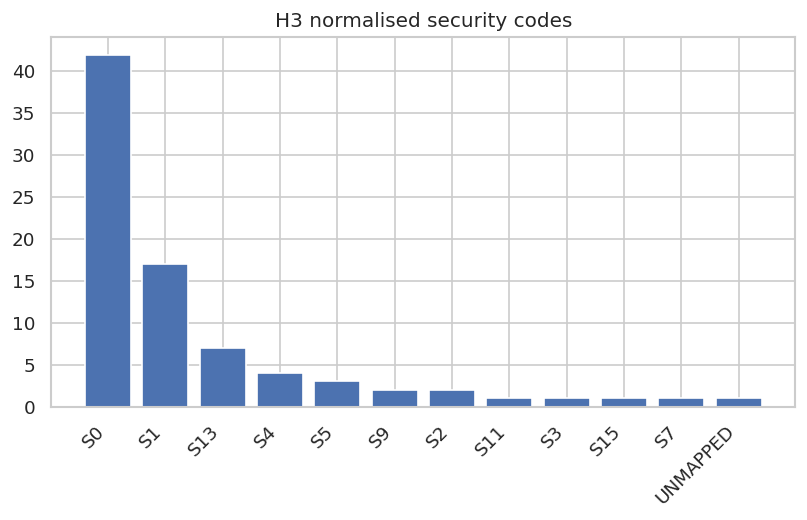

H3 audit review complete.


In [5]:
review_ids = rd.select_review_topics(
    h3,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    force_ids=app["topic_id"].tolist(),
    per_code=3,
    seed=42,
)
packs = rd.show_review_set(
    cfg,
    h3,
    review_ids,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    code_col=CODE_COL,
)
ctx.save_markdown(
    rd.render_review_markdown(packs, title="H3 security / material — close-reading pack"),
    "close_reading_pack",
)
ctx.save_table(
    h3[
        [
            "topic_id",
            "current_topic_label",
            "current_taxonomy_id",
            "current_taxonomy_name",
            "security_code",
            "code_norm",
            "mixed_topic",
        ]
    ],
    "security_topic_annotations",
)

fig, ax = plt.subplots(figsize=(8, 4))
vc = h3["code_norm"].fillna("UNMAPPED").value_counts()
ax.bar(vc.index.astype(str), vc.values)
ax.set_title("H3 normalised security codes")
plt.xticks(rotation=45, ha="right")
ctx.save_figure(fig, "h3_code_distribution")
plt.show()

print("H3 audit review complete.")